# Image Classification: CNN for Grayscale Images (PyTorch)

This notebook builds an image classifier from scratch using a CNN over grayscale pixels. Dataset: Fashion-MNIST (70,000 28x28 grayscale images, 10 classes: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot).

Same overall pipeline as before:
1. Get the data
2. Profile the data
3. Wrap into a PyTorch Dataset
4. Split into train / validation / test
5. Build the model: Conv2d blocks -> global pool -> Dropout -> Linear
6. Train, tracking train vs. validation loss/accuracy each epoch
7. Final evaluation on the held-out test set
8. Inference on a new image
9. Save the model

The main change from the earlier version is that the input is a single grayscale channel instead of RGB, so the model uses 1-channel images.


## 0. Install & Import Libraries

In [3]:
# !pip install torch torchvision scikit-learn matplotlib --quiet

import random
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from PIL import Image

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 1. Get the Data

Fashion-MNIST already ships from `torchvision` with an official train/test split (60k/10k). To keep the same "one-time random split" pattern used elsewhere, we pool both official parts into one set of 70k images and re-split it ourselves below — this keeps the train/val/test ratio and split logic consistent across notebooks.


In [4]:
train_raw = torchvision.datasets.FashionMNIST(root="./data", train=True, download=True)
test_raw = torchvision.datasets.FashionMNIST(root="./data", train=False, download=True)

label_names = train_raw.classes
num_labels = len(label_names)

# Use a smaller subset for faster self-learning and lighter memory use.
MAX_TRAIN_IMAGES = 4000
MAX_TEST_IMAGES = 1000

images = np.concatenate([
    np.array(train_raw.data[:MAX_TRAIN_IMAGES]),
    np.array(test_raw.data[:MAX_TEST_IMAGES]),
], axis=0)
# .targets is a torch.Tensor on each split, so concatenate with torch.cat (not +,
# which tries elementwise addition and fails when the two slices have different lengths)
labels = torch.cat([
    train_raw.targets[:MAX_TRAIN_IMAGES],
    test_raw.targets[:MAX_TEST_IMAGES],
]).numpy()

print("Using reduced subset:")
print("  Train images:", MAX_TRAIN_IMAGES)
print("  Test images :", MAX_TEST_IMAGES)
print("Labels:", label_names)
print("Number of classes:", num_labels)
print("Total images:", images.shape[0], "| image shape:", images.shape[1:], "| dtype:", images.dtype)


100%|██████████| 26421880/26421880 [00:04<00:00, 5399741.86it/s] 


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 29515/29515 [00:00<00:00, 118100.88it/s]


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 4422102/4422102 [00:01<00:00, 2232404.47it/s]


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 5148/5148 [00:00<00:00, 4640506.55it/s]


Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



RuntimeError: The size of tensor a (4000) must match the size of tensor b (1000) at non-singleton dimension 0

## 2. Randomly Profile the Data

Look at random samples, label balance, and raw pixel value stats before building anything — same purpose as the text profiling step, catching obvious issues early (e.g. corrupted images, skewed classes, unexpected value ranges).

In [ ]:
sample_indices = random.sample(range(len(images)), 8)

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for ax, i in zip(axes, sample_indices):
    ax.imshow(images[i], cmap="gray")
    ax.set_title(label_names[labels[i]], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
unique, counts = np.unique(labels, return_counts=True)
print("Label distribution:")
for u, c in zip(unique, counts):
    print(f"  {label_names[u]:10s}: {c}")

print("\nPixel value range:", images.min(), "-", images.max())  # should be 0-255 (uint8, single grayscale channel)
print("Pixel mean (0-255 scale):", images.mean())
print("Pixel std  (0-255 scale):", images.std())


## 3. Transforms & PyTorch `Dataset`

Just like the tokenizer converted raw text -> model-ready tensors, `torchvision.transforms` converts raw pixel arrays -> model-ready tensors. The `Dataset` class below applies these **lazily inside `__getitem__`**, same lazy-processing pattern as the text notebooks (keeps memory low, since we're not pre-computing and storing every transformed image up front).

**Important: train gets different transforms than val/test.**
- `train_transform` includes **random crop + random horizontal flip** — this is *data augmentation*: randomly perturbing each training image a little differently every epoch, so the model can't just memorize exact pixel arrangements and is forced to learn more general, robust features. This is conceptually similar to what `Dropout` does for the FC layers, but applied to the raw input instead.
- `eval_transform` (used for val and test) has **no randomness** — evaluation needs to be deterministic and reproducible, so we only resize/normalize, never augment.
- Both apply `Normalize(mean, std)`: rescales pixel values from raw `0-255` down to roughly `-2..2`, using CIFAR-10's known per-channel mean/std. Neural networks train more stably on small, zero-centered inputs than on raw `0-255` integers.

In [ ]:
IMG_MEAN = (0.1307,)
IMG_STD = (0.3081,)

train_transform = transforms.Compose([
    transforms.RandomCrop(28, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMG_MEAN, IMG_STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMG_MEAN, IMG_STD),
])


In [ ]:
class ImageClassificationDataset(Dataset):
    """Wraps image arrays + labels into a PyTorch Dataset.
    Applies transforms lazily inside __getitem__ (mirrors lazy tokenization in the text notebooks)."""

    def __init__(self, images, labels, transform=None):
        self.images = images     # numpy array (N, H, W), uint8, single grayscale channel
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.fromarray(self.images[idx])   # numpy -> PIL Image, what torchvision transforms expect
        label = self.labels[idx]

        if self.transform is not None:
            image = self.transform(image)   # -> tensor (3, H, W), normalized

        return {
            "image": image,
            "label": torch.tensor(label, dtype=torch.long),
        }


## 4. Split into Train / Validation / Test (one-time random split)

Same two-step split as the text notebooks: carve off the test set first (held out completely until the final evaluation), then split the remainder into train/validation. Since images/labels are numpy arrays here (not plain lists), we split **indices** and index into the arrays afterward.

In [ ]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(images))

TEST_SIZE = 0.2   # 20% held out as final test set
VAL_SIZE = 0.1    # 10% of the ORIGINAL data used as validation set

temp_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=labels,
)

val_fraction_of_temp = VAL_SIZE / (1 - TEST_SIZE)

train_idx, val_idx = train_test_split(
    temp_idx,
    test_size=val_fraction_of_temp,
    random_state=SEED,
    stratify=labels[temp_idx],
)

print("Train size:", len(train_idx))
print("Val size  :", len(val_idx))
print("Test size :", len(test_idx))


In [ ]:
train_dataset = ImageClassificationDataset(images[train_idx], labels[train_idx], transform=train_transform)
val_dataset = ImageClassificationDataset(images[val_idx], labels[val_idx], transform=eval_transform)
test_dataset = ImageClassificationDataset(images[test_idx], labels[test_idx], transform=eval_transform)

print("Train size:", len(train_dataset))
print("Val size  :", len(val_dataset))
print("Test size :", len(test_dataset))

sample = train_dataset[0]
print("image shape:", sample["image"].shape, "| label:", sample["label"])


In [ ]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))
print("image shape:", batch["image"].shape)   # (batch, 1, 28, 28)
print("label shape:", batch["label"].shape)


## 5. Build the Model: CNN for Grayscale Images

- **Conv2d blocks**: each block is `Conv2d -> BatchNorm2d -> ReLU`, repeated twice, then `MaxPool2d(2)` halves the spatial size. `in_channels=1` on the very first conv because the input is a single grayscale channel; every later conv's `in_channels` matches the previous layer's `out_channels`.
- **BatchNorm2d**: normalizes activations within each mini-batch, which stabilizes and speeds up training — very standard in image CNNs.
- **3 blocks total**: channels grow `1 -> 32 -> 64 -> 128` while spatial size shrinks `28x28 -> 14x14 -> 7x7 -> 3x3` (the last MaxPool2d floors 7/2 down to 3). This is the classic CNN pattern: trade spatial resolution for a richer, more abstract feature representation at each stage.
- **`AdaptiveAvgPool2d(1)`**: averages each of the 128 channels down to a single number, producing a fixed-size `(batch, 128, 1, 1)` output regardless of the input's spatial size — this collapses the spatial representation into one fixed-length vector before the classifier head.
- **Classifier head**: `Flatten -> Dropout -> Linear`, mapping the 128-dim pooled vector to `num_labels` logits.


In [ ]:
class ImageCNNClassifier(nn.Module):
    def __init__(self, num_labels, in_channels=1, dropout=0.3):
        super().__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 28x28 -> 14x14
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 14x14 -> 7x7
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 7x7 -> 3x3
        )

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.classifier_head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, num_labels),
        )

    def forward(self, images):
        x = self.conv_block1(images)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.global_pool(x)
        logits = self.classifier_head(x)
        return logits


In [ ]:
model = ImageCNNClassifier(
    num_labels=num_labels,
    in_channels=1,   # single grayscale channel
    dropout=0.3,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


## 6. Loss Function & Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


## 7. Training Loop

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)
    for batch in progress_bar:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        progress_bar.set_postfix(loss=loss.item(), acc=correct / total)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Evaluating", leave=False)
    for batch in progress_bar:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        progress_bar.set_postfix(loss=loss.item(), acc=correct / total)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


In [ ]:
NUM_EPOCHS = 15

history = []

for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc="Epochs"):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)   # validation, NOT test

    history.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss, "val_acc": val_acc,
    })

    print(
        f"Epoch {epoch}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )


## 7a. Plot Training & Validation Curves

Visualize how loss and accuracy evolved for train vs. validation across epochs. A widening gap (train improving, val flat or worsening) is the classic overfitting signature; both curves plateauing together suggests the model has converged.


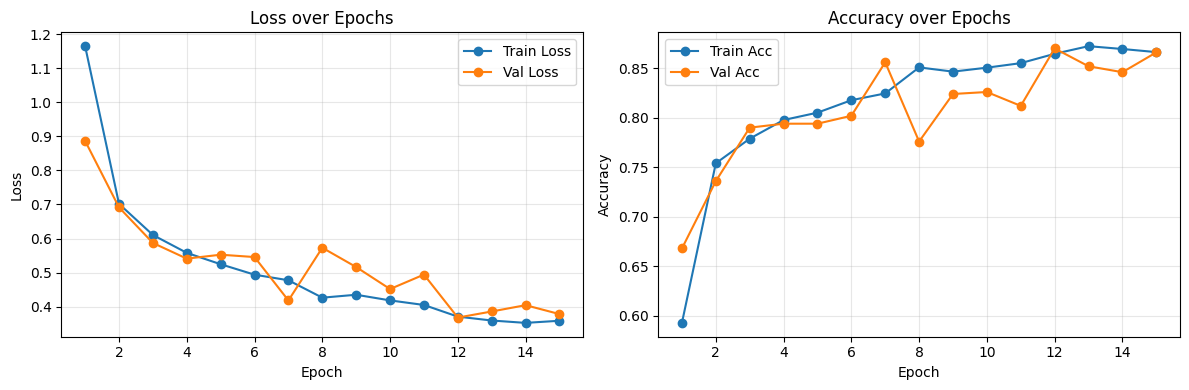

In [61]:
epochs = [h["epoch"] for h in history]
train_losses = [h["train_loss"] for h in history]
val_losses = [h["val_loss"] for h in history]
train_accs = [h["train_acc"] for h in history]
val_accs = [h["val_acc"] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_losses, label="Train Loss", marker="o")
axes[0].plot(epochs, val_losses, label="Val Loss", marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss over Epochs")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, train_accs, label="Train Acc", marker="o")
axes[1].plot(epochs, val_accs, label="Val Acc", marker="o")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy over Epochs")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 7b. Final Evaluation on the Held-Out Test Set

Run this **once**, after training/tuning is finished. The test set was never seen during training or used to make decisions about epochs/hyperparameters — that's what `val_loader` was for.

In [62]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Final Test Loss: {test_loss:.4f}, Final Test Acc: {test_acc:.4f}")


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Final Test Loss: 0.3841, Final Test Acc: 0.8440


## 8. Inference on a New Image

True label: Bag | Predicted: Bag (confidence: 0.8466)


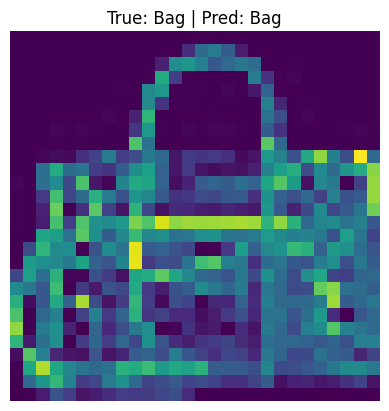

In [78]:
def predict(image, model, eval_transform, label_names, device):
    """image: a PIL Image (grayscale) or a path to an image file."""
    model.eval()

    if isinstance(image, str):
        image = Image.open(image).convert("L")

    tensor = eval_transform(image).unsqueeze(0).to(device)   # add batch dim -> (1, 3, H, W)

    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1).squeeze(0)
        pred_idx = torch.argmax(probs).item()

    return label_names[pred_idx], probs[pred_idx].item()


# Quick check using a test-set image (already a PIL-convertible array)

random_data_idx = random.choice(range(len(test_idx)))

sample_image = Image.fromarray(images[test_idx[random_data_idx]])
true_label = label_names[labels[test_idx[random_data_idx]]]

pred_label, confidence = predict(sample_image, model, eval_transform, label_names, device)
print(f"True label: {true_label} | Predicted: {pred_label} (confidence: {confidence:.4f})")

plt.imshow(sample_image)
plt.axis("off")
plt.title(f"True: {true_label} | Pred: {pred_label}")
plt.show()

# To predict on your own image file instead:
# pred_label, confidence = predict("/path/to/your/image.jpg", model, eval_transform, label_names, device)


## 9. Save the Model (optional)

Saves the full model state dict so you can reload it later without retraining.

In [60]:
# torch.save(model.state_dict(), "cnn_image_classifier.pt")
# print("Model saved to cnn_image_classifier.pt")

# To reload later:
model = ImageCNNClassifier(num_labels, in_channels=1, dropout=0.3)
model.load_state_dict(torch.load("cnn_image_classifier.pt", map_location=device))
model.to(device)


C:\Users\user\AppData\Local\Temp\ipykernel_9756\3826079664.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("cnn_image_classifier.pt", ma

ImageCNNClassifier(
  (conv_block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block3): Sequential

## 10. Bonus: Same Pipeline on a 3-Channel Dataset (CIFAR-10)

Everything above was built to be dataset-agnostic: `ImageClassificationDataset`, `ImageCNNClassifier`, `train_one_epoch`, `evaluate`, and `predict` don't hard-code anything about Fashion-MNIST. To reuse them on a **3-channel (RGB)** dataset, the only things that change are:

1. The raw data source (CIFAR-10 instead of Fashion-MNIST).
2. The normalization stats (per-channel mean/std instead of single-channel).
3. `in_channels=3` when constructing the model (instead of `1`).

We use **CIFAR-10** here: 10 classes, 32x32 color images, 60k train + 10k test — kept to a similar subset size (4000 train / 1000 test) as the grayscale example above so training time stays comparable.

Unlike the `torchvision.datasets.CIFAR10(download=True)` approach, we load it via Hugging Face `datasets` with `streaming=True`, which pulls examples on demand instead of downloading the full ~170MB archive up front. `.take(N)` stops as soon as it has the N examples we need.


In [82]:
# !pip install datasets --quiet

import os
from datasets import load_dataset

MAX_TRAIN_IMAGES_RGB = 4000
MAX_TEST_IMAGES_RGB = 1000

DATA_DIR_RGB = "./data_3channels"
os.makedirs(DATA_DIR_RGB, exist_ok=True)
IMAGES_PATH_RGB = os.path.join(DATA_DIR_RGB, "images_rgb.npy")
LABELS_PATH_RGB = os.path.join(DATA_DIR_RGB, "labels_rgb.npy")
LABEL_NAMES_PATH_RGB = os.path.join(DATA_DIR_RGB, "label_names_rgb.npy")

if os.path.exists(IMAGES_PATH_RGB) and os.path.exists(LABELS_PATH_RGB) and os.path.exists(LABEL_NAMES_PATH_RGB):
    # Already saved locally from a previous run - load straight from disk, no re-streaming needed.
    images_rgb = np.load(IMAGES_PATH_RGB)
    labels_rgb = np.load(LABELS_PATH_RGB)
    label_names_rgb = np.load(LABEL_NAMES_PATH_RGB, allow_pickle=True).tolist()
    num_labels_rgb = len(label_names_rgb)
    print("Loaded cached subset from", DATA_DIR_RGB)
else:
    # Stream instead of full-download: CIFAR-10's official archive is ~170MB (60k train + 10k test),
    # but we only need 5000 images total. streaming=True pulls examples on demand, and .take(N)
    # stops after N examples instead of pulling the whole split.
    train_stream = load_dataset("cifar10", split="train", streaming=True)
    test_stream = load_dataset("cifar10", split="test", streaming=True)

    label_names_rgb = train_stream.features["label"].names
    num_labels_rgb = len(label_names_rgb)

    train_examples_rgb = list(train_stream.take(MAX_TRAIN_IMAGES_RGB))
    test_examples_rgb = list(test_stream.take(MAX_TEST_IMAGES_RGB))

    images_rgb = np.stack(
        [np.array(ex["img"]) for ex in train_examples_rgb] +
        [np.array(ex["img"]) for ex in test_examples_rgb]
    )
    labels_rgb = np.array(
        [ex["label"] for ex in train_examples_rgb] +
        [ex["label"] for ex in test_examples_rgb]
    )

    # Save the subset to data_3channels so future runs can load from disk instead of streaming again.
    np.save(IMAGES_PATH_RGB, images_rgb)
    np.save(LABELS_PATH_RGB, labels_rgb)
    np.save(LABEL_NAMES_PATH_RGB, np.array(label_names_rgb, dtype=object))
    print("Saved subset to", DATA_DIR_RGB)

print("Using reduced subset:")
print("  Train images:", MAX_TRAIN_IMAGES_RGB)
print("  Test images :", MAX_TEST_IMAGES_RGB)
print("Labels:", label_names_rgb)
print("Number of classes:", num_labels_rgb)
print("Total images:", images_rgb.shape[0], "| image shape:", images_rgb.shape[1:], "| dtype:", images_rgb.dtype)


Loaded cached subset from ./data_3channels
Using reduced subset:
  Train images: 4000
  Test images : 1000
Labels: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of classes: 10
Total images: 5000 | image shape: (32, 32, 3) | dtype: uint8


### 10a. Quick Profile

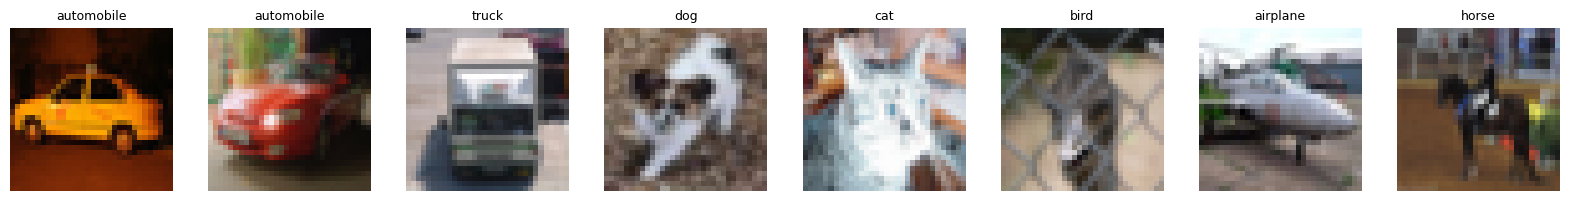

Label distribution:
  airplane  : 489
  automobile: 460
  bird      : 522
  cat       : 472
  deer      : 525
  dog       : 503
  frog      : 509
  horse     : 492
  ship      : 531
  truck     : 497

Pixel value range: 0 - 255
Per-channel mean (0-255 scale): [125.90573457 123.40243789 114.11482441]
Per-channel std  (0-255 scale): [62.92798473 61.98918056 66.80806572]


In [85]:
sample_indices_rgb = random.sample(range(len(images_rgb)), 8)

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for ax, i in zip(axes, sample_indices_rgb):
    ax.imshow(images_rgb[i])
    ax.set_title(label_names_rgb[labels_rgb[i]], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

unique_rgb, counts_rgb = np.unique(labels_rgb, return_counts=True)
print("Label distribution:")
for u, c in zip(unique_rgb, counts_rgb):
    print(f"  {label_names_rgb[u]:10s}: {c}")

print("\nPixel value range:", images_rgb.min(), "-", images_rgb.max())  # 0-255, uint8, RGB
print("Per-channel mean (0-255 scale):", images_rgb.reshape(-1, 3).mean(axis=0))
print("Per-channel std  (0-255 scale):", images_rgb.reshape(-1, 3).std(axis=0))


### 10b. Transforms & Dataset/Split

Same `ImageClassificationDataset` class, `train_test_split` logic, and `DataLoader` setup as before — just with CIFAR-10's known per-channel mean/std, and `RandomCrop(32, ...)` to match the 32x32 image size.

In [86]:
IMG_MEAN_RGB = (0.4914, 0.4822, 0.4465)
IMG_STD_RGB = (0.2470, 0.2435, 0.2616)

train_transform_rgb = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMG_MEAN_RGB, IMG_STD_RGB),
])

eval_transform_rgb = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMG_MEAN_RGB, IMG_STD_RGB),
])

indices_rgb = np.arange(len(images_rgb))

temp_idx_rgb, test_idx_rgb = train_test_split(
    indices_rgb, test_size=TEST_SIZE, random_state=SEED, stratify=labels_rgb,
)
train_idx_rgb, val_idx_rgb = train_test_split(
    temp_idx_rgb, test_size=val_fraction_of_temp, random_state=SEED, stratify=labels_rgb[temp_idx_rgb],
)

train_dataset_rgb = ImageClassificationDataset(images_rgb[train_idx_rgb], labels_rgb[train_idx_rgb], transform=train_transform_rgb)
val_dataset_rgb = ImageClassificationDataset(images_rgb[val_idx_rgb], labels_rgb[val_idx_rgb], transform=eval_transform_rgb)
test_dataset_rgb = ImageClassificationDataset(images_rgb[test_idx_rgb], labels_rgb[test_idx_rgb], transform=eval_transform_rgb)

train_loader_rgb = DataLoader(train_dataset_rgb, batch_size=BATCH_SIZE, shuffle=True)
val_loader_rgb = DataLoader(val_dataset_rgb, batch_size=BATCH_SIZE, shuffle=False)
test_loader_rgb = DataLoader(test_dataset_rgb, batch_size=BATCH_SIZE, shuffle=False)

print("Train size:", len(train_dataset_rgb))
print("Val size  :", len(val_dataset_rgb))
print("Test size :", len(test_dataset_rgb))

batch_rgb = next(iter(train_loader_rgb))
print("image shape:", batch_rgb["image"].shape)   # (batch, 3, 32, 32)


Train size: 3500
Val size  : 500
Test size : 1000
image shape: torch.Size([64, 3, 32, 32])


### 10c. Model, Loss & Optimizer

Same `ImageCNNClassifier` class — just `in_channels=3` this time.

In [87]:
model_rgb = ImageCNNClassifier(
    num_labels=num_labels_rgb,
    in_channels=3,   # RGB
    dropout=0.3,
).to(device)

total_params_rgb = sum(p.numel() for p in model_rgb.parameters())
print(f"Total params: {total_params_rgb:,}")

criterion_rgb = nn.CrossEntropyLoss()
optimizer_rgb = torch.optim.Adam(model_rgb.parameters(), lr=1e-3)


Total params: 289,194


### 10d. Training Loop

Reuses the same `train_one_epoch` / `evaluate` functions defined earlier.

In [88]:
NUM_EPOCHS_RGB = 15

history_rgb = []

for epoch in tqdm(range(1, NUM_EPOCHS_RGB + 1), desc="Epochs"):
    train_loss_rgb, train_acc_rgb = train_one_epoch(model_rgb, train_loader_rgb, optimizer_rgb, criterion_rgb, device)
    val_loss_rgb, val_acc_rgb = evaluate(model_rgb, val_loader_rgb, criterion_rgb, device)

    history_rgb.append({
        "epoch": epoch,
        "train_loss": train_loss_rgb, "train_acc": train_acc_rgb,
        "val_loss": val_loss_rgb, "val_acc": val_acc_rgb,
    })

    print(
        f"Epoch {epoch}/{NUM_EPOCHS_RGB} | "
        f"Train Loss: {train_loss_rgb:.4f}, Train Acc: {train_acc_rgb:.4f} | "
        f"Val Loss: {val_loss_rgb:.4f}, Val Acc: {val_acc_rgb:.4f}"
    )


Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

Training:   0%|          | 0/55 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 1/15 | Train Loss: 1.9423, Train Acc: 0.2626 | Val Loss: 1.8320, Val Acc: 0.3160


Training:   0%|          | 0/55 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 14/15 | Train Loss: 0.9986, Train Acc: 0.6417 | Val Loss: 1.2890, Val Acc: 0.5840


Training:   0%|          | 0/55 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 15/15 | Train Loss: 0.9482, Train Acc: 0.6600 | Val Loss: 1.2008, Val Acc: 0.5980


### 10e. Plot Training & Validation Curves

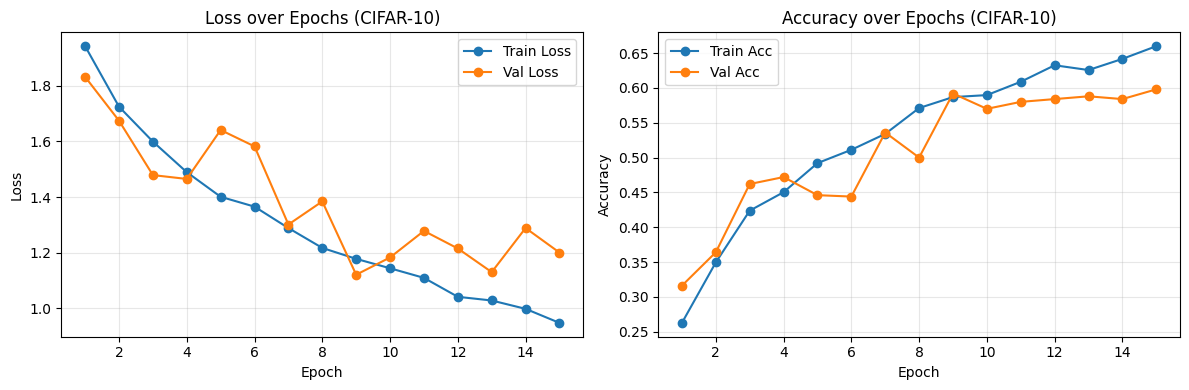

In [89]:
epochs_rgb = [h["epoch"] for h in history_rgb]
train_losses_rgb = [h["train_loss"] for h in history_rgb]
val_losses_rgb = [h["val_loss"] for h in history_rgb]
train_accs_rgb = [h["train_acc"] for h in history_rgb]
val_accs_rgb = [h["val_acc"] for h in history_rgb]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_rgb, train_losses_rgb, label="Train Loss", marker="o")
axes[0].plot(epochs_rgb, val_losses_rgb, label="Val Loss", marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss over Epochs (CIFAR-10)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_rgb, train_accs_rgb, label="Train Acc", marker="o")
axes[1].plot(epochs_rgb, val_accs_rgb, label="Val Acc", marker="o")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy over Epochs (CIFAR-10)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 10f. Final Evaluation on the Held-Out Test Set

In [90]:
test_loss_rgb, test_acc_rgb = evaluate(model_rgb, test_loader_rgb, criterion_rgb, device)
print(f"Final Test Loss: {test_loss_rgb:.4f}, Final Test Acc: {test_acc_rgb:.4f}")


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Final Test Loss: 1.2545, Final Test Acc: 0.5750


### 10g. Inference on a New Image

True label: ship | Predicted: cat (confidence: 0.2288)


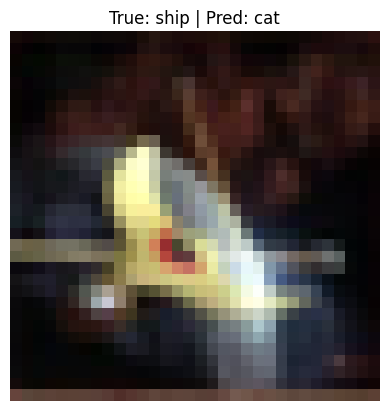

In [107]:


random_data_idx_rgb = random.choice(range(len(test_idx_rgb)))

sample_image_rgb = Image.fromarray(images_rgb[test_idx_rgb[random_data_idx_rgb]])
true_label_rgb = label_names_rgb[labels_rgb[test_idx_rgb[random_data_idx_rgb]]]

pred_label_rgb, confidence_rgb = predict(sample_image_rgb, model_rgb, eval_transform_rgb, label_names_rgb, device)
print(f"True label: {true_label_rgb} | Predicted: {pred_label_rgb} (confidence: {confidence_rgb:.4f})")

plt.imshow(sample_image_rgb)
plt.axis("off")
plt.title(f"True: {true_label_rgb} | Pred: {pred_label_rgb}")
plt.show()

# To predict on your own image file instead:
# pred_label_rgb, confidence_rgb = predict("/path/to/your/image.jpg", model_rgb, eval_transform_rgb, label_names_rgb, device)


### 10h. Save the Model (optional)

In [92]:
torch.save(model_rgb.state_dict(), "cnn_image_classifier_rgb.pt")
print("Model saved to cnn_image_classifier_rgb.pt")

# To reload later:
# model_rgb = ImageCNNClassifier(num_labels_rgb, in_channels=3, dropout=0.3)
# model_rgb.load_state_dict(torch.load("cnn_image_classifier_rgb.pt", map_location=device))
# model_rgb.to(device)


Model saved to cnn_image_classifier_rgb.pt
